# Day 6: Classify Text Sentiment

In [1]:
# GPU Check & Verification
import torch
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Device:", torch.cuda.get_device_name(0))

# Run nvidia-smi if on Colab / GPU instance
!nvidia-smi


CUDA Available: True
GPU Device: Tesla T4
Tue Jul 21 18:51:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords', quiet=True)

True

## 1. Load Data

In [3]:
# Load the Amazon Fine Food Reviews dataset

url = "https://media.githubusercontent.com/media/Vvijayaragupathy-uno/machinelearning/main/Day-6/Reviews.csv"
data = pd.read_csv(url)

print(data.head())

   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of the Vitality canned d...  
1 

## 2. Understanding the Data (EDA)

Data Shape:
(568454, 10)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB
None

Missing Values:
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       

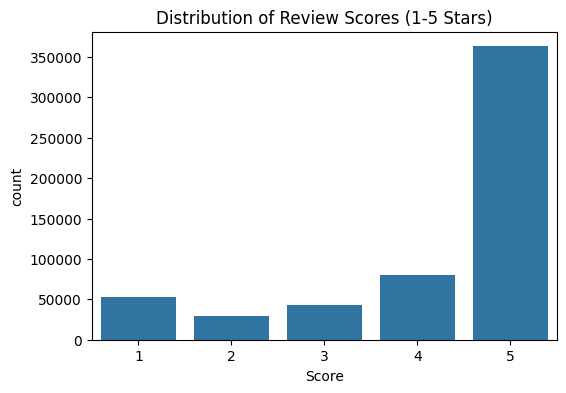

In [4]:
# Check how many rows and columns
print("Data Shape:")
print(data.shape)

# Check data types
print("\nData Info:")
print(data.info())

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Plot the distribution of review scores (1 to 5 stars)
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='Score')
plt.title("Distribution of Review Scores (1-5 Stars)")
plt.show()

## 3. Data Cleaning & Sentiment Labeling

In [5]:
# Filter out neutral reviews (Score == 3) for binary classification
data = data[data['Score'] != 3]

# Create binary sentiment label: 1 for Positive (4-5 stars), 0 for Negative (1-2 stars)
data['Sentiment'] = data['Score'].apply(lambda x: 1 if x > 3 else 0)

# Drop rows with missing text if any
data = data.dropna(subset=['Text'])

print("Sentiment Distribution:")
print(data['Sentiment'].value_counts())

Sentiment Distribution:
Sentiment
1    443777
0     82037
Name: count, dtype: int64


## 4. Text Preprocessing Pipeline

In [6]:
# Setup Stopwords and Stemmer
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    # 1. Lowercase text
    text = str(text).lower()
    # 2. Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # 3. Tokenize into words
    words = text.split()
    # 4. Remove stopwords & apply Stemming
    cleaned = [stemmer.stem(word) for word in words if word not in stop_words]
    # 5. Rejoin into string
    return ' '.join(cleaned)

# Apply preprocessing to our reviews
data['Clean_Text'] = data['Text'].apply(preprocess_text)

print("Original Review:")
print(data['Text'].iloc[0])
print("\nCleaned & Preprocessed Review:")
print(data['Clean_Text'].iloc[0])

Original Review:
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.

Cleaned & Preprocessed Review:
bought sever vital can dog food product found good qualiti product look like stew process meat smell better labrador finicki appreci product better


## 5. Feature Extraction (TF-IDF)

In [7]:
X = data['Clean_Text']
y = data['Sentiment']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Extract TF-IDF Features
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Train Matrix Shape:", X_train_tfidf.shape)
print("TF-IDF Test Matrix Shape:", X_test_tfidf.shape)

TF-IDF Train Matrix Shape: (420651, 5000)
TF-IDF Test Matrix Shape: (105163, 5000)


## 6. Model Training & Evaluation

In [8]:
# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# Predict on test data
y_pred = model.predict(X_test_tfidf)

# Calculate Accuracy & F1-Score
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy Score:", round(accuracy, 4))
print("F1 Score:", round(f1, 4))

Accuracy Score: 0.9278
F1 Score: 0.958


## 7. Top 10 Most Important Words per Class

In [9]:
# Get vocabulary feature names and model weights
feature_names = np.array(tfidf.get_feature_names_out())
coefficients = model.coef_[0]

# Top 10 words indicating Negative Sentiment (lowest weights)
top_neg_idx = coefficients.argsort()[:10]
top_neg_words = feature_names[top_neg_idx]

# Top 10 words indicating Positive Sentiment (highest weights)
top_pos_idx = coefficients.argsort()[-10:][::-1]
top_pos_words = feature_names[top_pos_idx]

# Summary DataFrame
top_words_df = pd.DataFrame({
    'Top 10 Negative Words': top_neg_words,
    'Top 10 Positive Words': top_pos_words
})

display(top_words_df)

,Top 10 Negative Words,Top 10 Positive Words
0,worst,great
1,disappoint,delici
2,terribl,best
3,aw,perfect
4,unfortun,love
5,horribl,highli
6,return,excel
7,disgust,awesom
8,yuck,amaz
9,tasteless,yummi
